In [12]:
import argparse
import os
import pickle
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from torch.utils.data import Subset
from tqdm.auto import tqdm

import autoslo.utils.paths as pu
from autoslo.blueprint_selection.query_timeline import QueryTimeline
from autoslo.models.iconq_model import IconqModel
from autoslo.models.model_prediction import ModelPrediction
from autoslo.nn.concurrent_query_dataset import ConcurrentQueryDataset
from autoslo.utils.colors import Palette
from autoslo.workload_execution.trace import Trace




In [13]:
iconq_model_id = '1769376434'

model = IconqModel.load(
    model_id=iconq_model_id,
)

trained_on_log_runtime = model.trained_on_log_runtime

model_dir = os.path.join(
    pu.get_data_path(),
    "iconq_models",
    iconq_model_id,
)

overall_dataset_path = os.path.join(model_dir, "dataset.pkl")
dataset = ConcurrentQueryDataset.load_from(overall_dataset_path)
split_datasets = {}
for split in ["train", "val", "test"]:
    with open(
        os.path.join(model_dir, f"{split}_indices.pkl"),
        "rb",
    ) as f:
        indices = pickle.load(f)
    split_datasets[split] = Subset(dataset=dataset, indices=indices)


split_true_y = {}
split_predicted_y_1 = {}
split_predicted_y_2 = {}

for split_idx, split in enumerate(["train", "val", "test"]):
    split_dataset = split_datasets[split]

    true_y_d = {}
    for i in range(len(split_dataset)):
        _, _, y, query_id, _, _, _ = split_dataset[i]
        true_y_d[query_id] = (
            y.item() if not trained_on_log_runtime else np.exp(y.item())
        )
    split_true_y[split] = pd.Series(true_y_d)

    split_predicted_y_1[split] = model.predict_from_dataset(
        dataset=split_dataset,
    )
    split_predicted_y_2[split] = model.predict_from_dataset(
        dataset=split_dataset,
    )



Loading model checkpoint from /home/markakis/chunkbench/data/iconq_models/1769376434/model_1769377368.pth


In [14]:
split_predicted_y_1['test']['cluster_8_4473960#862279d2-a9ad-4090-b856-dd06b922380d']

ModelPrediction(mean_s=[np.float32(0.43186915)], std_dev_s=None, mix_coeffs=None, metadata={'num_other_concurrent_queries': 0, 'run_id': '1763249132', 'tpcds_temp_and_q_idx': '055_003', 'query_id': 'cluster_8_4473960#862279d2-a9ad-4090-b856-dd06b922380d', 'target_is_lower_bound': tensor(False), 'loss': 0.0})

In [15]:
original_predictions_path = "/home/markakis/chunkbench/data/iconq_models/1769376434/val_predictions_10.csv"

df = pd.read_csv(original_predictions_path)

# Extract value from
# ModelPrediction(mean_s=array([3027.8955], dtype=float32),
df["mean_pred_s"] = df["y_pred"].apply(
    lambda x: float(
        x.strip("ModelPrediction(mean_s=array([").rsplit("]")[0]
    )
)

original_predictions = {
    row["query_id"].split('#')[0]: row["mean_pred_s"] for _, row in df.iterrows()
}

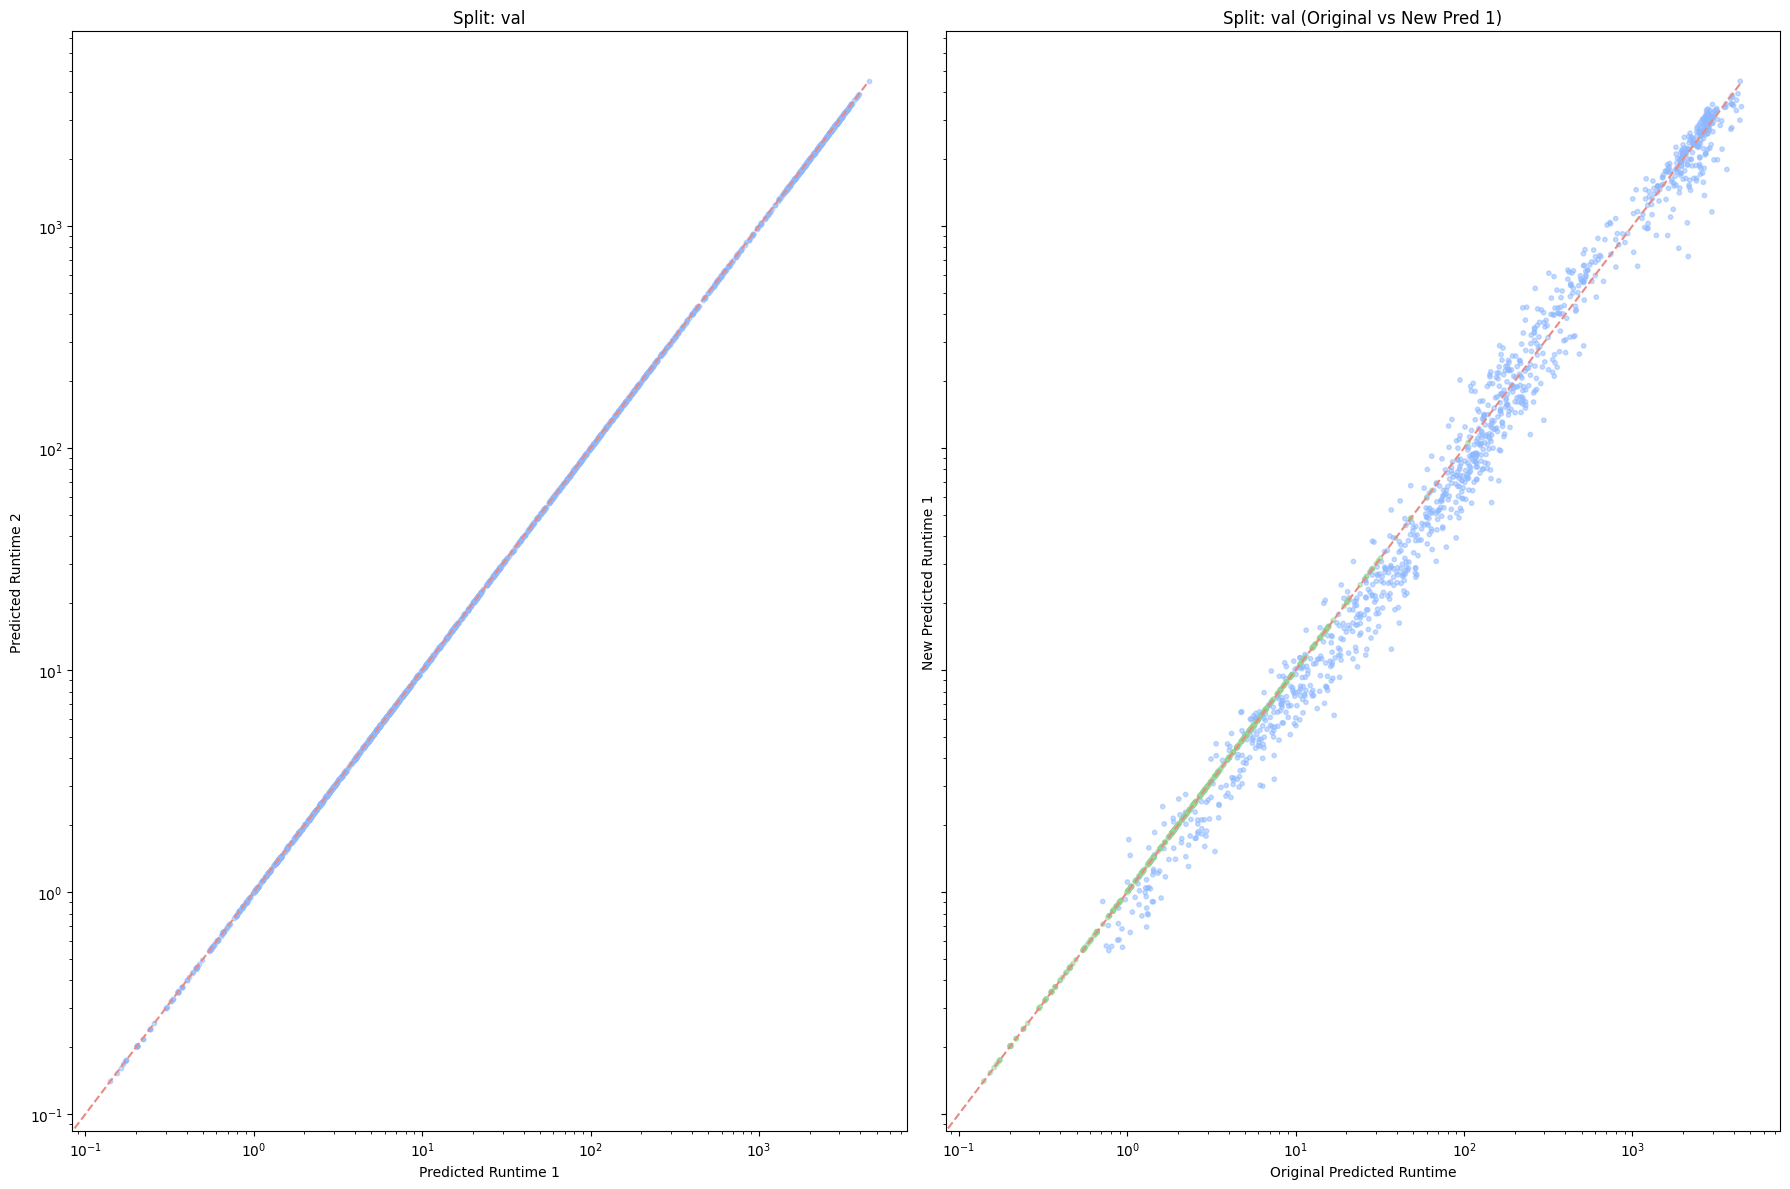

In [16]:
# Plot a scatter plot of the two predictions to see how different they are
fig, axs = plt.subplots(1, 2, figsize=(18, 12), sharex=True, sharey=True)
split = 'val'

# First plot the two new predictions against each other
ax = axs[0]
split_predictions_1 = split_predicted_y_1[split]
split_predictions_2 = split_predicted_y_2[split]

x_vals = []
y_vals = []

for query_id in split_predictions_1.keys():
    x_vals.append(split_predictions_1[query_id].overall_mean_s())
    y_vals.append(split_predictions_2[query_id].overall_mean_s())

ax.scatter(
    x=x_vals,
    y=y_vals,
    c=Palette.light_blue,
    alpha=0.5,
    s=10,
)
max_val = max(
    max(x_vals),
    max(y_vals),
)

ax.plot([0, max_val], [0, max_val], c=Palette.light_red, linestyle="--")
ax.set_title(f"Split: {split}")
ax.set_xlabel("Predicted Runtime 1")
ax.set_ylabel("Predicted Runtime 2")
ax.set_xscale("log")
ax.set_yscale("log")


# In the second row, plot the original predictions vs the new predictions 1
ax = axs[1]

x_vals = []
y_vals = []
colors = []
for query_id in split_predictions_1.keys():
    x_vals.append(original_predictions[query_id.strip().split('#')[0]])
    y_vals.append(split_predictions_1[query_id].overall_mean_s())
    colors.append(Palette.light_green if split_predictions_1[query_id].metadata['num_other_concurrent_queries'] == 0 else Palette.light_blue)

ax.scatter(
    x=x_vals,
    y=y_vals,
    c=colors,
    alpha=0.5,
    s=10,
)
max_val = max(
    max(x_vals),
    max(y_vals),
)

# 

ax.plot([0, max_val], [0, max_val], c=Palette.light_red, linestyle="--")
ax.set_title(f"Split: {split} (Original vs New Pred 1)")
ax.set_xlabel("Original Predicted Runtime")
ax.set_ylabel("New Predicted Runtime 1")
ax.set_xscale("log")
ax.set_yscale("log")
plt.tight_layout()
plt.show()